In [1]:
%pip install numpy
%pip install scipy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [33]:
import math
import numpy as np
from scipy.integrate import ode
from matplotlib import pyplot as plt

In [183]:
G = 9.8
EPSILON = 1e-3

def solve_rolling(r: float, friction: float, alpha: float, v0: float, w0: float, max_t: float, dt: float = 0.01):
    state_0 = [0, v0, w0]

    def derivatives(_, state: tuple[float, float, float]):
        gravity_a = G * math.sin(alpha)

        _, v, w = state

        v_contact = v - w * r

        max_friction_a = friction * G * math.cos(alpha)
        stable_friction_a = min(2 / 7 * gravity_a, max_friction_a)
        if v_contact > EPSILON:
            friction_a = max_friction_a
        elif v_contact < -EPSILON:
            friction_a = -max_friction_a
        else:
            friction_a = stable_friction_a

        derivatives = [
            v,
            gravity_a - friction_a,
            friction_a / (2 / 5 * r)
        ]
        return derivatives

    integrator = ode(derivatives)
    integrator.set_initial_value(state_0, 0)
    integrator.set_integrator('dopri5', rtol=1e-6)

    t_values = []
    path_values = []
    v_values = []
    w_values = []
    is_slipping = []

    while integrator.successful() and integrator.t < max_t:
        path, v, w = integrator.integrate(integrator.t + dt)
        t_values.append(integrator.t)
        path_values.append(path)
        v_values.append(v)
        w_values.append(w)
        is_slipping.append(abs(v - w * r) > EPSILON)

    return (np.array(t_values), np.array(path_values), np.array(v_values),
            np.array(w_values), np.array(is_slipping))

In [201]:
R = 1
t, path, v, w, is_rolling = solve_rolling(R, 0.1, math.pi / 4, 0.0, 30.0, 10)

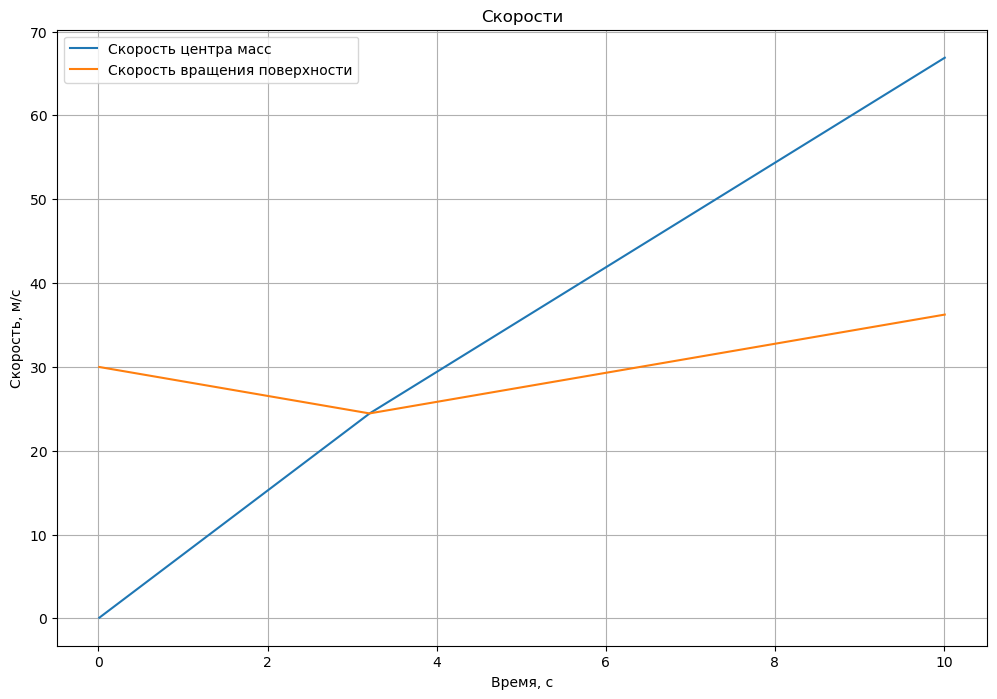

In [202]:
plt.figure(figsize=(12, 8))

plt.plot(t, v, label='Скорость центра масс')
plt.plot(t, w * R, label='Скорость вращения поверхности')

plt.title('Скорости')
plt.xlabel('Время, с')
plt.ylabel('Скорость, м/с')
plt.legend()
plt.grid(True)
plt.show()
